In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/raw/Walmart_Sales.csv', parse_dates=['Date'])

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
df.head(10)

✅ Dataset loaded!
Shape: (6435, 8)

Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [3]:
print("Date Range:", df['Date'].min(), "→", df['Date'].max())
print("Total Stores:", df['Store'].nunique())
print("Total Records:", len(df))
df.describe()

Date Range: 01-04-2011 → 31-12-2010
Total Stores: 45
Total Records: 6435


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [5]:
# Check current dtype
print("Date dtype:", df['Date'].dtype)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Confirm
print("Fixed dtype:", df['Date'].dtype)
df['Date'].head()

Date dtype: str
Fixed dtype: datetime64[us]


0   2011-04-01
1   2011-04-01
2   2011-04-01
3   2011-04-01
4   2011-04-01
Name: Date, dtype: datetime64[us]

## EDA 

In [6]:
df = df.sort_values('Date').reset_index(drop=True)

# Extract date features
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['week']        = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['Date'].dt.quarter
df['day_of_week'] = df['Date'].dt.dayofweek

# Lag features (weekly data so lag 4 = 1 month ago)
df['sales_lag_1']      = df['Weekly_Sales'].shift(1)
df['sales_lag_4']      = df['Weekly_Sales'].shift(4)
df['sales_lag_52']     = df['Weekly_Sales'].shift(52)
df['rolling_mean_4']   = df['Weekly_Sales'].rolling(4).mean()
df['rolling_mean_12']  = df['Weekly_Sales'].rolling(12).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("✅ Preprocessing done!")
print("New Shape:", df.shape)
df.head()

✅ Preprocessing done!
New Shape: (6383, 18)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,quarter,day_of_week,sales_lag_1,sales_lag_4,sales_lag_52,rolling_mean_4,rolling_mean_12
0,29,2010-02-12,529672.95,1,28.14,2.771,131.586613,10.064,2010,2,6,1,4,294882.83,1015684.09,890689.51,1.032222e+06,1.176428e+06
1,34,2010-02-12,994610.99,1,36.13,2.573,126.496258,9.521,2010,2,6,1,4,529672.95,1558968.49,1034119.21,8.911324e+05,1.133675e+06
2,39,2010-02-12,1266229.07,1,44.58,2.548,209.997021,8.554,2010,2,6,1,4,994610.99,1745362.72,1874289.79,7.713490e+05,1.039078e+06
3,36,2010-02-12,469563.70,1,46.11,2.539,209.997021,8.554,2010,2,6,1,4,1266229.07,294882.83,1672352.29,8.150192e+05,1.011659e+06
4,37,2010-02-12,529852.70,1,46.11,2.548,209.997021,8.554,2010,2,6,1,4,469563.70,529672.95,538634.46,8.150641e+05,9.641430e+05


C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1101368160.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1101368160.py:8: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('../outputs/sales_trend.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


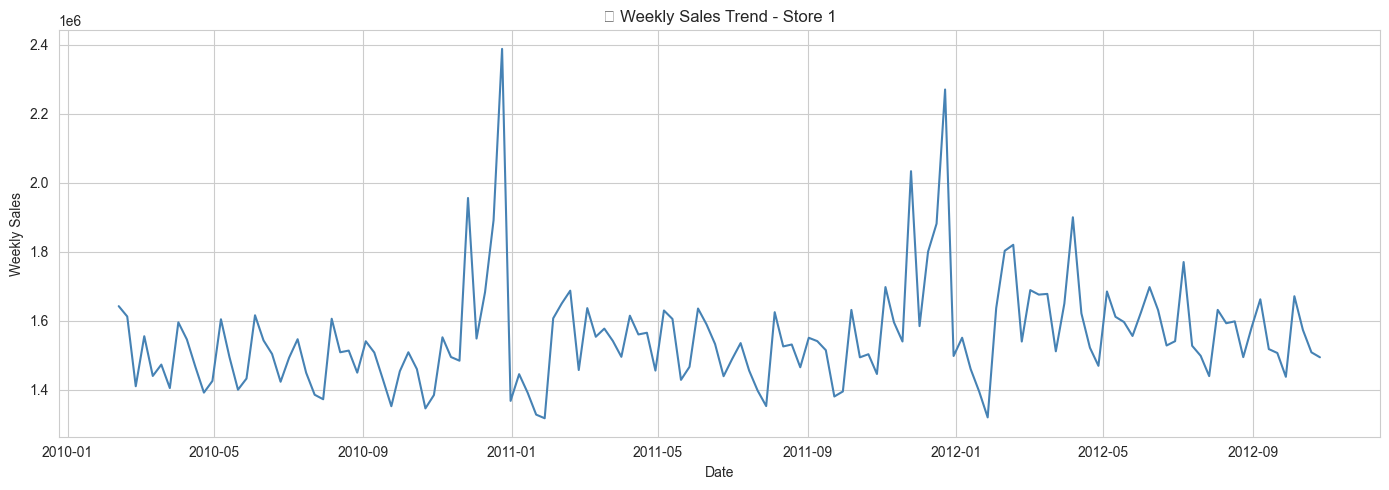

In [7]:
plt.figure()
store1 = df[df['Store'] == 1]
plt.plot(store1['Date'], store1['Weekly_Sales'], color='steelblue')
plt.title('📈 Weekly Sales Trend - Store 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.savefig('../outputs/sales_trend.png')
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2840443563.py:9: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2840443563.py:10: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig('../outputs/monthly_pattern.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


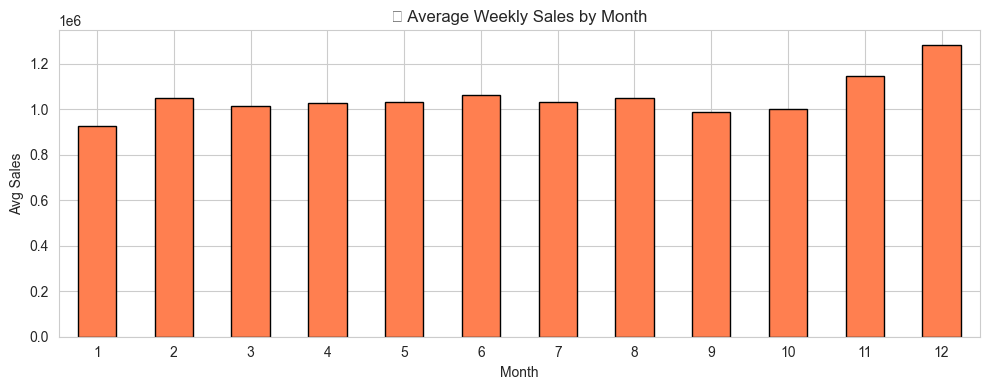

In [8]:
monthly = df.groupby('month')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='coral', edgecolor='black')
plt.title('📅 Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/monthly_pattern.png')
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\3005401257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set1')
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\3005401257.py:5: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\3005401257.py:5: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\3005401257.py:6: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.savefig('../outputs/holiday_impact.png')
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\3005401257.py:6: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('../output

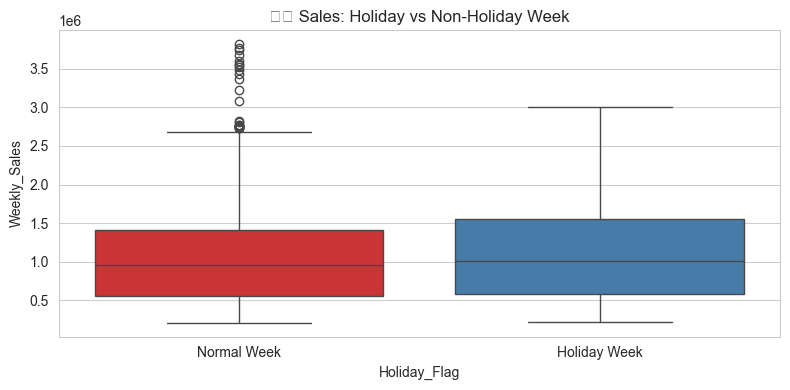

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set1')
plt.title('🏷️ Sales: Holiday vs Non-Holiday Week')
plt.xticks([0, 1], ['Normal Week', 'Holiday Week'])
plt.tight_layout()
plt.savefig('../outputs/holiday_impact.png')
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\4007962504.py:9: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\4007962504.py:10: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Arial.
  plt.savefig('../outputs/top_stores.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


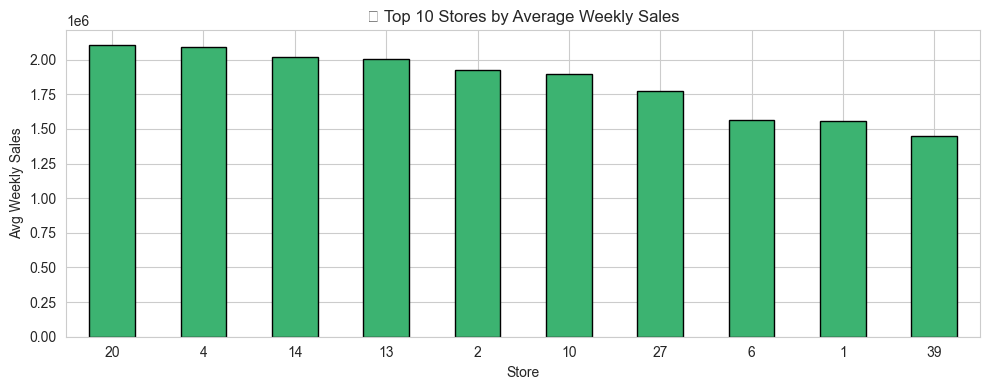

In [10]:
top_stores = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_stores.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('🏪 Top 10 Stores by Average Weekly Sales')
plt.xlabel('Store')
plt.ylabel('Avg Weekly Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/top_stores.png')
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2557450893.py:9: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2557450893.py:10: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.savefig('../outputs/correlation_heatmap.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


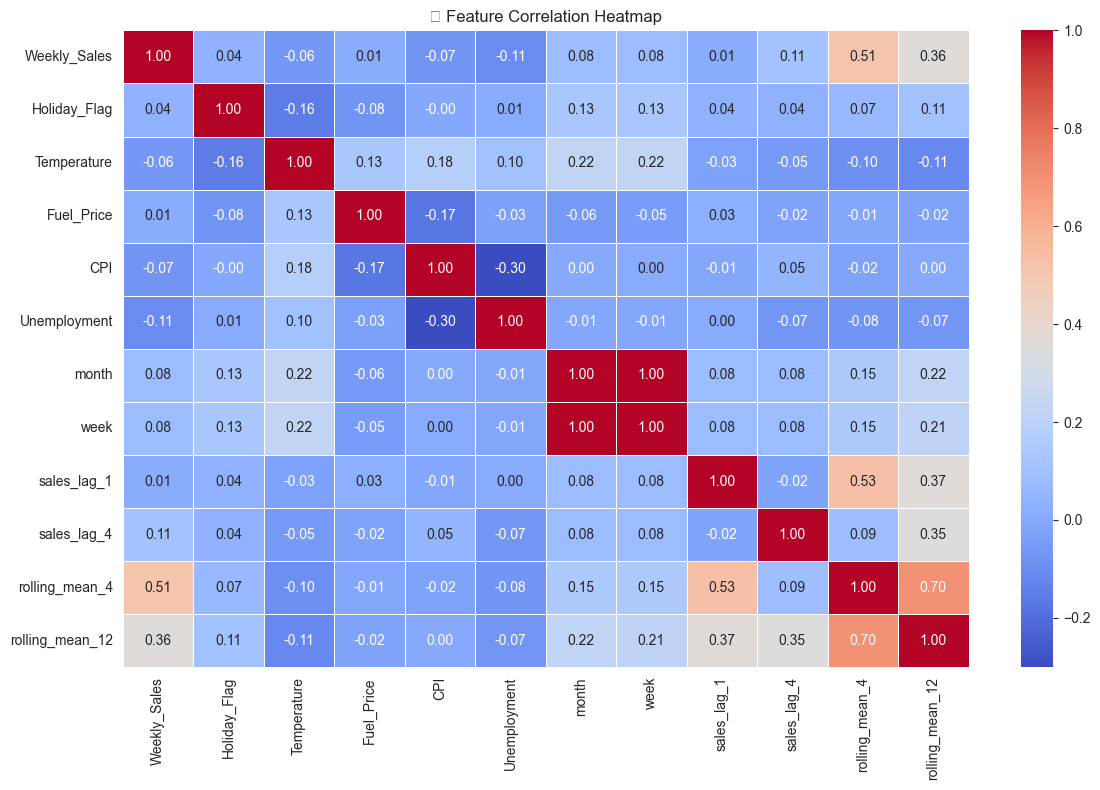

In [11]:
cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
        'CPI', 'Unemployment', 'month', 'week',
        'sales_lag_1', 'sales_lag_4', 'rolling_mean_4', 'rolling_mean_12']

plt.figure(figsize=(12, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('🔥 Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png')
plt.show()

## Model Building

In [12]:
from sklearn.model_selection import train_test_split

features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
            'CPI', 'Unemployment', 'year', 'month', 'week', 'quarter',
            'sales_lag_1', 'sales_lag_4', 'sales_lag_52',
            'rolling_mean_4', 'rolling_mean_12']

X = df[features]
y = df['Weekly_Sales']

# Keep time order — don't shuffle!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

print("✅ Data split done!")
print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

✅ Data split done!
Training size: (5106, 15)
Testing size : (1277, 15)


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("✅ Random Forest trained!")

✅ Random Forest trained!


C:\Users\rahul\AppData\Local\Temp\ipykernel_8488\2653063235.py:9: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_8488\2653063235.py:10: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) Arial.
  plt.savefig('../outputs/day_of_week.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


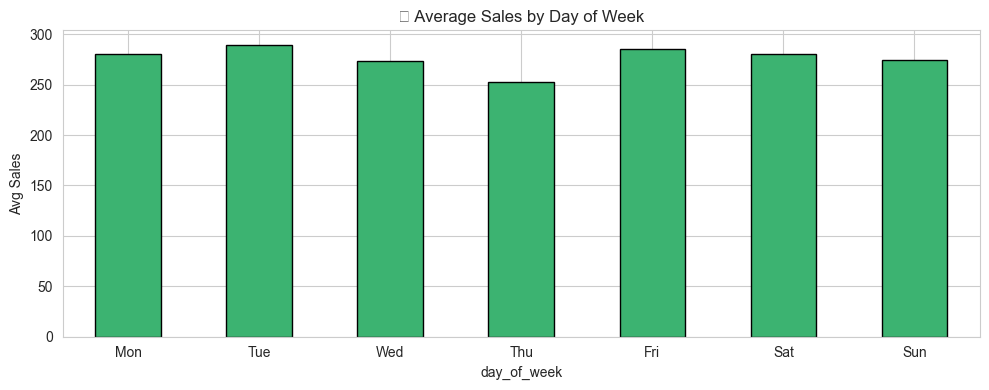

In [12]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df.groupby('day_of_week')['sales'].mean()

plt.figure(figsize=(10, 4))
dow.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('📆 Average Sales by Day of Week')
plt.xticks(ticks=range(7), labels=days, rotation=0)
plt.ylabel('Avg Sales')
plt.tight_layout()
plt.savefig('../outputs/day_of_week.png')
plt.show()

In [14]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("✅ XGBoost trained!")

✅ XGBoost trained!


In [15]:
from prophet import Prophet

# Use Store 1 only for Prophet
store1 = df[df['Store'] == 1][['Date', 'Weekly_Sales']].rename(
    columns={'Date': 'ds', 'Weekly_Sales': 'y'})

split = int(len(store1) * 0.8)
train_prophet = store1.iloc[:split]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
            daily_seasonality=False)
m.fit(train_prophet)

future   = m.make_future_dataframe(periods=len(store1) - split, freq='W')
forecast = m.predict(future)

prophet_preds  = forecast['yhat'].tail(len(store1) - split).values
prophet_actual = store1['y'].iloc[split:].values

print("✅ Prophet trained!")

09:08:58 - cmdstanpy - INFO - Chain [1] start processing
09:08:58 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet trained!


C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1315262251.py:9: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1315262251.py:10: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  plt.savefig('../outputs/actual_vs_predicted.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


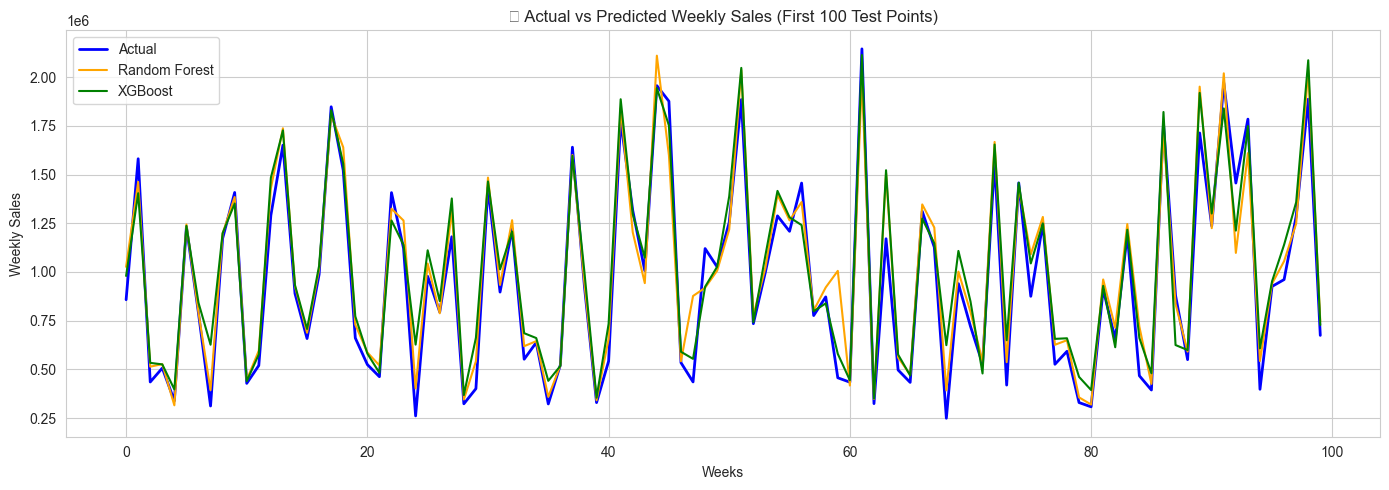

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100],  label='Actual',        color='blue',   linewidth=2)
plt.plot(rf_preds[:100],       label='Random Forest', color='orange', linewidth=1.5)
plt.plot(xgb_preds[:100],      label='XGBoost',       color='green',  linewidth=1.5)
plt.title('🔮 Actual vs Predicted Weekly Sales (First 100 Test Points)')
plt.xlabel('Weeks')
plt.ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png')
plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100
    
    print(f"\n📊 {name}")
    print(f"   MAE  : {mae:.2f}")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   MAPE : {mape:.2f}%")
    
    return {'Model': name, 'MAE': round(mae, 2),
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

In [18]:
results = []
results.append(evaluate("Random Forest", y_test, rf_preds))
results.append(evaluate("XGBoost",       y_test, xgb_preds))
results.append(evaluate("Prophet",       prophet_actual, prophet_preds))


📊 Random Forest
   MAE  : 86777.17
   RMSE : 132496.20
   MAPE : 9.81%

📊 XGBoost
   MAE  : 86371.21
   RMSE : 119375.62
   MAPE : 10.91%

📊 Prophet
   MAE  : 65193.18
   RMSE : 81006.14
   MAPE : 4.18%


In [19]:
results_df = pd.DataFrame(results).sort_values('RMSE')

print("\n🏆 Model Comparison (sorted by RMSE):")
results_df


🏆 Model Comparison (sorted by RMSE):


,Model,MAE,RMSE,MAPE
2,Prophet,65193.18,81006.14,4.18
1,XGBoost,86371.21,119375.62,10.91
0,Random Forest,86777.17,132496.20,9.81


C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1261624652.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\1261624652.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig('../outputs/model_comparison.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


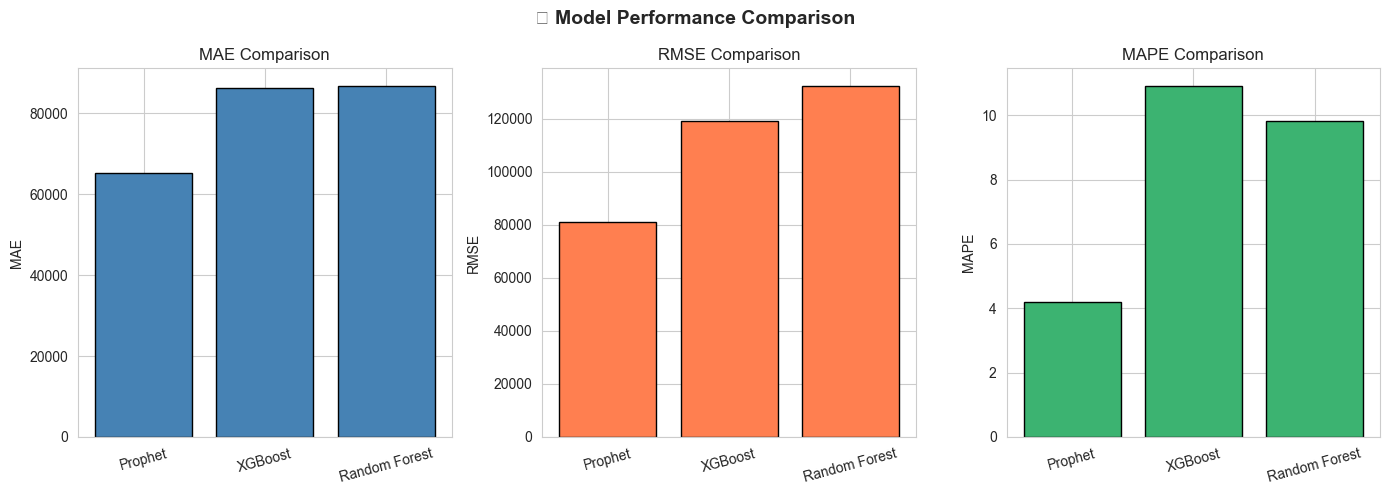

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric],
                color=colors[i], edgecolor='black')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('📊 Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2353266220.py:11: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rahul\AppData\Local\Temp\ipykernel_21956\2353266220.py:12: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.savefig('../outputs/feature_importance.png')
C:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


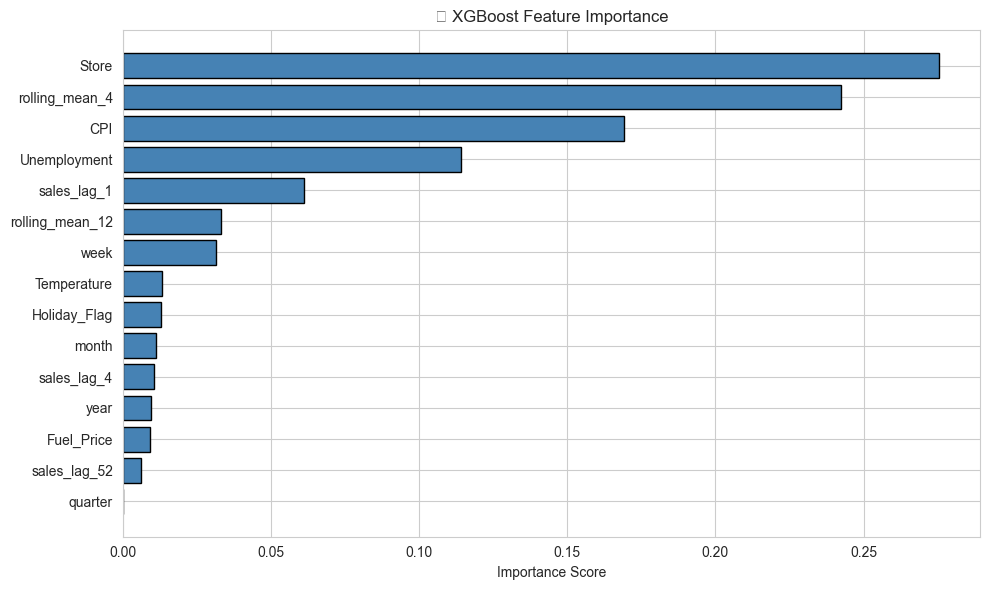

In [21]:
importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='black')
plt.title('🔍 XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

In [22]:
import joblib

joblib.dump(rf_model,  '../models/random_forest_walmart.pkl')
joblib.dump(xgb_model, '../models/xgboost_walmart.pkl')

print("✅ Models saved!")

✅ Models saved!


In [23]:
print("=" * 55)
print("   DEMAND FORECASTING — WALMART DATASET SUMMARY")
print("=" * 55)
print("\n📁 Dataset       : Walmart Sales (Kaggle)")
print("📅 Date Range    : 2010 – 2012 (Weekly)")
print("🏪 Total Stores  : 45")
print("📊 Total Records : 6435 rows")
print("🧹 After Preprocessing:", df.shape[0], "rows,", df.shape[1], "columns")
print("\n🤖 Models Trained:")
print("   ✅ Random Forest")
print("   ✅ XGBoost")
print("   ✅ Prophet (Store 1)")
print(f"\n🏆 Best Model : {results_df.iloc[0]['Model']}")
print(f"   MAE  : {results_df.iloc[0]['MAE']}")
print(f"   RMSE : {results_df.iloc[0]['RMSE']}")
print(f"   MAPE : {results_df.iloc[0]['MAPE']}%")
print("\n💾 Saved Models:")
print("   models/xgboost_walmart.pkl")
print("   models/random_forest_walmart.pkl")
print("\n✅ Project Complete!")
print("=" * 55)

   DEMAND FORECASTING — WALMART DATASET SUMMARY

📁 Dataset       : Walmart Sales (Kaggle)
📅 Date Range    : 2010 – 2012 (Weekly)
🏪 Total Stores  : 45
📊 Total Records : 6435 rows
🧹 After Preprocessing: 6383 rows, 18 columns

🤖 Models Trained:
   ✅ Random Forest
   ✅ XGBoost
   ✅ Prophet (Store 1)

🏆 Best Model : Prophet
   MAE  : 65193.18
   RMSE : 81006.14
   MAPE : 4.18%

💾 Saved Models:
   models/xgboost_walmart.pkl
   models/random_forest_walmart.pkl

✅ Project Complete!
